<a href="https://colab.research.google.com/github/MeghnaMadhuNair/explainable-churn-analytics/blob/main/notebooks/01_telco_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

dataset_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(dataset_url)

df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nChurn distribution:")
print(df["Churn"].value_counts())


Rows and columns: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(df.dtypes)

print("\nBlank TotalCharges values:",
      (df["TotalCharges"].str.strip() == "").sum())

print("Duplicate customer IDs:",
      df["customerID"].duplicated().sum())

print("Churn rate:",
      round((df["Churn"] == "Yes").mean() * 100, 2), "%")

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Blank TotalCharges values: 11
Duplicate customer IDs: 0
Churn rate: 26.54 %


In [ ]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df_clean[["TotalCharges", "SeniorCitizen", "Churn"]].dtypes)
print("Missing TotalCharges:", df_clean["TotalCharges"].isna().sum())

TotalCharges     float64
SeniorCitizen     object
Churn              int64
dtype: object
Missing TotalCharges: 11


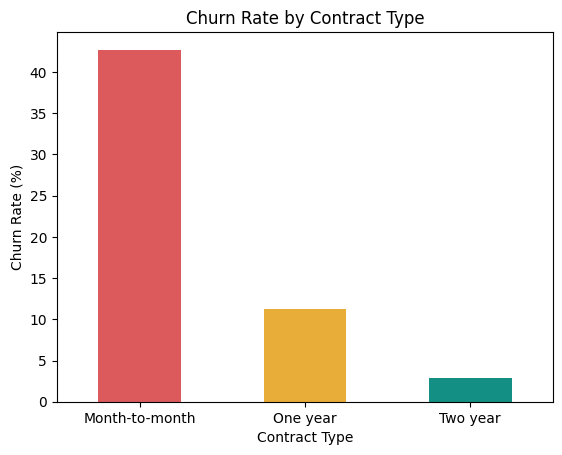

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

contract_churn = (
    df_clean.groupby("Contract")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_churn.plot(
    kind="bar",
    color=["#dc5a5b", "#e8ad38", "#148f83"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

print(contract_churn)

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["customerID", "Churn"])
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [ ]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

model_pipeline.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_pred = model_pipeline.predict(X_test)
y_probability = model_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 score:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_probability), 3))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.737
Precision: 0.503
Recall: 0.783
F1 score: 0.613
ROC-AUC: 0.841

Confusion matrix:
[[746 289]
 [ 81 293]]


In [ ]:
!pip install -q shap

In [ ]:
import shap

print("SHAP installed successfully.")

SHAP installed successfully.


In [ ]:
fitted_preprocessor = model_pipeline.named_steps["preprocessor"]
trained_model = model_pipeline.named_steps["model"]

X_train_transformed = fitted_preprocessor.transform(X_train)
X_test_transformed = fitted_preprocessor.transform(X_test)

feature_names = fitted_preprocessor.get_feature_names_out()

masker = shap.maskers.Independent(
    X_train_transformed,
    max_samples=1000
)

explainer = shap.LinearExplainer(
    trained_model,
    masker
)

shap_values = explainer(X_test_transformed)

print("SHAP values shape:", shap_values.values.shape)
print("Number of feature names:", len(feature_names))

SHAP values shape: (1409, 46)
Number of feature names: 46


Customer ID: 5178-LMXOP
Predicted churn risk: 93.8 %
Actual churn: 1


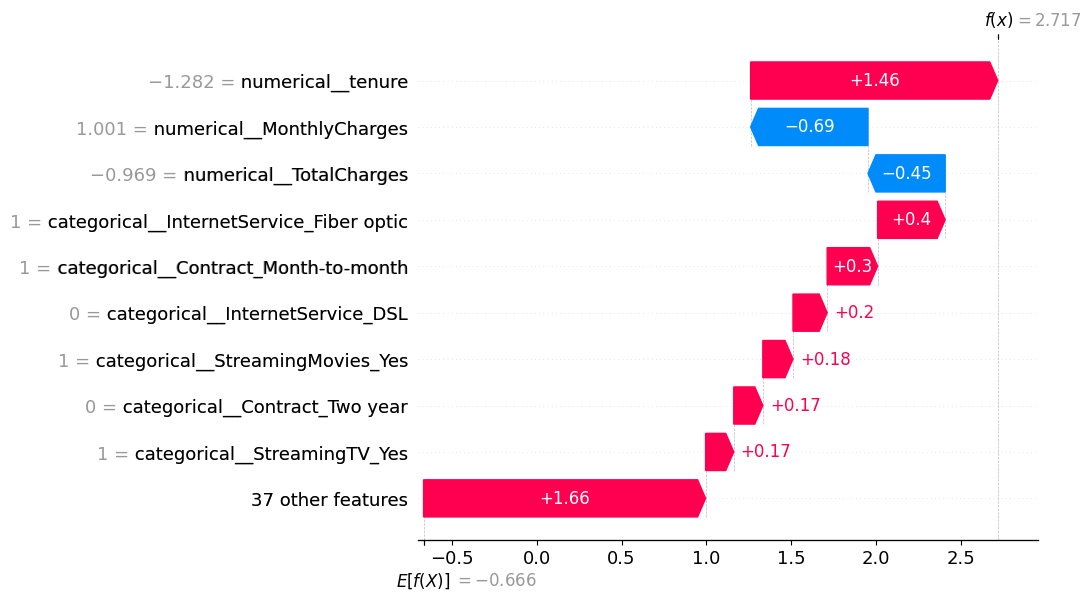

In [ ]:
import numpy as np
import pandas as pd

X_test_processed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

highest_risk_position = np.argmax(y_probability)

customer_shap = explainer(
    X_test_processed.iloc[[highest_risk_position]]
)

customer_index = X_test.index[highest_risk_position]

print("Customer ID:", df_clean.loc[customer_index, "customerID"])
print("Predicted churn risk:",
      round(y_probability[highest_risk_position] * 100, 2), "%")
print("Actual churn:",
      df_clean.loc[customer_index, "Churn"])

shap.plots.waterfall(customer_shap[0], max_display=10)

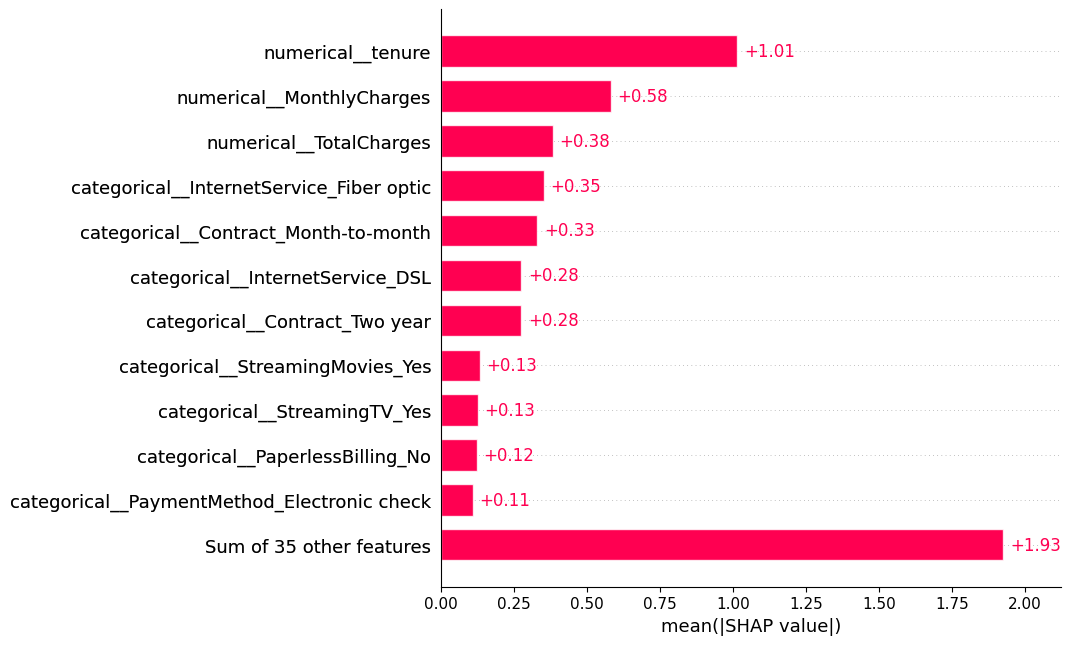

In [ ]:
shap_values_named = explainer(X_test_processed)

shap.plots.bar(
    shap_values_named,
    max_display=12
)

In [ ]:
original_customer = X_test.iloc[[highest_risk_position]].copy()
scenario_customer = original_customer.copy()

scenario_customer["Contract"] = "Two year"
scenario_customer["TechSupport"] = "Yes"
scenario_customer["OnlineSecurity"] = "Yes"
scenario_customer["PaymentMethod"] = "Credit card (automatic)"

original_risk = model_pipeline.predict_proba(
    original_customer
)[0, 1]

scenario_risk = model_pipeline.predict_proba(
    scenario_customer
)[0, 1]

print("Original risk:", round(original_risk * 100, 2), "%")
print("Scenario risk:", round(scenario_risk * 100, 2), "%")
print("Difference:",
      round((scenario_risk - original_risk) * 100, 2),
      "percentage points")

Original risk: 93.8 %
Scenario risk: 57.7 %
Difference: -36.1 percentage points


In [ ]:
import plotly.express as px

X_all = df_clean.drop(columns=["customerID", "Churn"])

dashboard_data = df_clean[
    ["customerID", "MonthlyCharges", "Contract", "Churn"]
].copy()

dashboard_data["PredictedRisk"] = (
    model_pipeline.predict_proba(X_all)[:, 1]
)

fig = px.scatter(
    dashboard_data,
    x="MonthlyCharges",
    y="PredictedRisk",
    color="PredictedRisk",
    hover_data=["customerID", "Contract", "Churn"],
    color_continuous_scale="RdYlGn_r",
    title="Customer Risk-Value Grid"
)

fig.add_hline(y=0.65, line_dash="dash")
fig.add_vline(x=75, line_dash="dash")

fig.update_yaxes(tickformat=".0%")
fig.show()

In [ ]:
import plotly.graph_objects as go

contracts = df_clean["Contract"].unique().tolist()
services = df_clean["InternetService"].unique().tolist()
outcomes = ["Retained", "Churned"]

labels = (
    ["Contract: " + value for value in contracts] +
    ["Internet: " + value for value in services] +
    ["Outcome: " + value for value in outcomes]
)

label_index = {
    label: index for index, label in enumerate(labels)
}

sources = []
targets = []
values = []

contract_service = (
    df_clean.groupby(["Contract", "InternetService"])
    .size()
    .reset_index(name="count")
)

for _, row in contract_service.iterrows():
    sources.append(label_index["Contract: " + row["Contract"]])
    targets.append(label_index["Internet: " + row["InternetService"]])
    values.append(row["count"])

service_outcome = (
    df_clean.assign(
        Outcome=df_clean["Churn"].map({
            0: "Retained",
            1: "Churned"
        })
    )
    .groupby(["InternetService", "Outcome"])
    .size()
    .reset_index(name="count")
)

for _, row in service_outcome.iterrows():
    sources.append(label_index["Internet: " + row["InternetService"]])
    targets.append(label_index["Outcome: " + row["Outcome"]])
    values.append(row["count"])

figure = go.Figure(go.Sankey(
    node=dict(label=labels),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

figure.update_layout(
    title="Customer Profile Flow",
    height=500
)

figure.show()

In [ ]:
from google.colab import drive
import joblib
import os

drive.mount("/content/drive")

project_folder = "/content/drive/MyDrive/churn_thesis"
os.makedirs(project_folder, exist_ok=True)

joblib.dump(
    model_pipeline,
    project_folder + "/churn_model.joblib"
)

dashboard_data.to_csv(
    project_folder + "/dashboard_data.csv",
    index=False
)

print("Files saved in:", project_folder)

Mounted at /content/drive
Files saved in: /content/drive/MyDrive/churn_thesis
